# Ejemplos utilizando librería Pandas



Empezamos importando la librería Pandas y numpy

In [7]:
import pandas as pd
import numpy as np


Para entender cómo generamos un dataset con Pandas, lo comparamos con un vector convencional

In [8]:
myvector = np.array([1,2,3,4,5])
print("myvector:")
print(myvector)



myvector:
[1 2 3 4 5]


In [9]:
mydf1 = pd.DataFrame(myvector)
print("mydf1:")
mydf1

mydf1:


,0
0,1
1,2
2,3
3,4
4,5


El nuevo dataframe creado, tiene índices de filas y de columnas.
Probamos a generar uno desde un array de dos dimensiones (una matriz)

In [10]:
myarray = np.array([[10,30,20], [50,40,60],[1000,2000,3000]])
print("myarray:")
print(myarray)
print()


myarray:
[[  10   30   20]
 [  50   40   60]
 [1000 2000 3000]]



In [11]:
mydf2 = pd.DataFrame(myarray)
print("mydf2:")
mydf2

mydf2:


,0,1,2
0,10,30,20
1,50,40,60
2,1000,2000,3000


En los elementos anteriores, se aprecia que los dataframes de pandas ponen claves de filas y columnas por defecto, que serán números si no damos otro tipo de claves. Vamos a crear un df ahora en forma de diccionario:

In [12]:
names = pd.Series(['SF', 'San Jose', 'Sacramento'])
sizes = pd.Series([852469, 1015785, 485199])
df = pd.DataFrame({ 'Cities': names, 'Size': sizes })
df

,Cities,Size
0,SF,852469
1,San Jose,1015785
2,Sacramento,485199


Los índices de las columnas se han tomado a partir de las claves del diccionario. Pero también podemos crear un dataframe desde un array y asignar después los valores de índices de las filas y de las columnas

In [13]:
myarray = np.array([[10,30,20], [50,40,60],[1000,2000,3000]])
rownames = ['lentejas', 'espinacas', 'cerveza']
colnames = ['enero', 'febrero', 'marzo']
mydf = pd.DataFrame(myarray, index=rownames, columns=colnames)
print("Compras:")
mydf


Compras:


,enero,febrero,marzo
lentejas,10,30,20
espinacas,50,40,60
cerveza,1000,2000,3000


Si solo queremos ver los datos de enero

In [14]:
print("Compras de enero:")
mydf['enero']

Compras de enero:


,enero
lentejas,10
espinacas,50
cerveza,1000


Si queremos saber la cantidad de elementos en cada dimensión:

In [15]:
print("Número de filas:")
print(mydf.shape[0])
print()
print("Número de columnas:")
mydf.shape[1]

Número de filas:
3

Número de columnas:


3

O ver las dimensiones en conjunto:

In [16]:
print("Número de filas y columnas:")
print(mydf.shape)

Número de filas y columnas:
(3, 3)


También podemos consultar los nombres o etiquetas de filas o columnas, que son los valores que habíamos asignado a los índices, así como el tipo de valor que son.

In [17]:
print("Columnas:")
print(mydf.columns)
print()
print("Column types:")
mydf.dtypes

Columnas:
Index(['enero', 'febrero', 'marzo'], dtype='object')

Column types:


,0
enero,int64
febrero,int64
marzo,int64


La función "describe" es muy útil, pues nos devuelve los datos estadísticos principales de la distribución de datos

In [18]:
print("Valores estadísticos de los datos:")
mydf.describe()

Valores estadísticos de los datos:


,enero,febrero,marzo
count,3.000000,3.000000,3.000000
mean,353.333333,690.000000,1026.666667
std,560.386771,1134.504297,1709.073823
min,10.000000,30.000000,20.000000
25%,30.000000,35.000000,40.000000
50%,50.000000,40.000000,60.000000
75%,525.000000,1020.000000,1530.000000
max,1000.000000,2000.000000,3000.000000


También podemos hacer una representación gráfica básica de los datos

<Axes: >

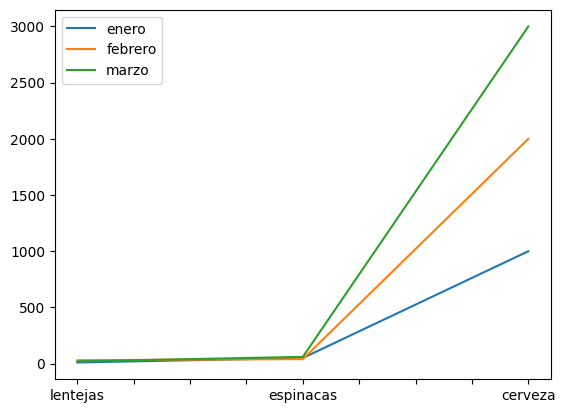

In [19]:
mydf.plot()

A veces, vamos a necesitar trasponer un dataframe, esto es, cambiar las filas por las columnas, y lo hacemos con la función T

In [20]:
df1 = pd.DataFrame({'a': [1, 0, 1], 'b': [0, 1, 1] },
dtype=int)
print(df1)
print("df1.T:")
print(df1.T)

   a  b
0  1  0
1  0  1
2  1  1
df1.T:
   0  1  2
a  1  0  1
b  0  1  1


Si lo aplicamos a nuestro dataframe de las compras:

<Axes: >

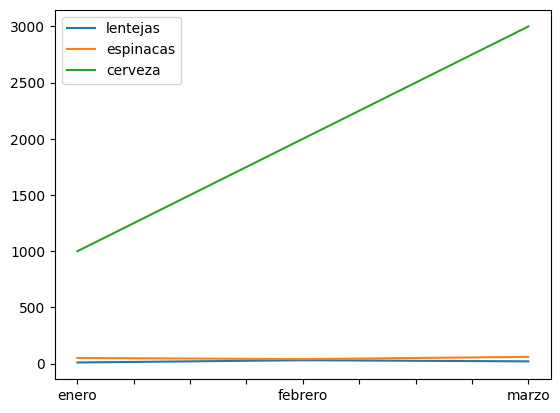

In [21]:
df = mydf.T
df.plot()

Viendo el gráfico, podemos concluir que vamos a tener que incentivar de alguna manera el consumo de lentejas y espinacas frente al de cerveza 😅

Probemos ahora a sumar dataframes valor a valor

In [22]:
df1 = pd.DataFrame({'a' : [1, 0, 1], 'b' : [0, 1, 1] },
dtype=int)
df2 = pd.DataFrame({'a' : [3, 3, 3], 'b' : [5, 5, 5] },
dtype=int)
print("df1 + df2:")
print(df1 + df2)

df1 + df2:
   a  b
0  4  5
1  3  6
2  4  6


Algo que vamos a necesitar más de una vez, será convertir datos de tipo categórico a numérico. Esta opción es la más básica, y es adecuada para casos de valores binarios. Puedes descargar el archivo 'spam_no_spam.tsv' necesario para este ejemplo, [aquí](https://drive.google.com/file/d/1o3zlsYxTlU7JyJTzdJF9ClF-AF2-QAGZ/view?usp=sharing)

In [23]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('/content/spam_no_spam.tsv', delimiter='\t')
print("Primeras cinco líneas:")
print(df.head(5))
print("-------------------------")
# mapeamos no_spam/spam a valores 0/1 respectivamente:
df['type'] = df['type'].map( {'no_spam':0 , 'spam':1} )
print("Primeras cinco líneas despues del cambio:")
print(df.head(5))
print("-------------------------")

Saving spam_no_spam.tsv to spam_no_spam.tsv
Primeras cinco líneas:
      type                          text
0  no_spam  Ya esta disponible su pedido
1  no_spam           Revise sus mensajes
2     spam            Un iPhone gratis!!
3  no_spam           Un 20% de descuento
4  no_spam    Tienes un nuevo comentario
-------------------------
Primeras cinco líneas despues del cambio:
   type                          text
0     0  Ya esta disponible su pedido
1     0           Revise sus mensajes
2     1            Un iPhone gratis!!
3     0           Un 20% de descuento
4     0    Tienes un nuevo comentario
-------------------------


En este otro ejemplo, utilizamos replace para sustituir las categorías de talla de camisetas por el valor numérico. El archivo para este ejemplo, puedes descargarlo [aquí](https://drive.google.com/file/d/1Q2696bRiBilF3DOpmPyFSOBcz2EiJunx/view?usp=sharing). El parámetro regex corresponde a "regular expresions", y aunque suele ser de tipo booleano, en casos como éste, toma como valor una cadena. Si quieres saber más, puedes consultar la [documentación de Pandas sobre la función replace](https://pandas.pydata.org/docs/reference/api/pandas.Series.replace.html).

In [25]:
from google.colab import files
uploaded = files.upload()

shirts = pd.read_csv("shirts.csv")
print("shirts before:")
print(shirts)
print()
shirts['size'] = shirts['size'].replace(regex='xlarge',
value=4)
shirts['size'] = shirts['size'].replace(regex='large',
value=3)
shirts['size'] = shirts['size'].replace(regex='medium',
value=2)
shirts['size'] = shirts['size'].replace(regex='small',
value=1)
print("shirts after:")
print(shirts)

Saving shirts.csv to shirts.csv
shirts before:
     type     size
0   shirt  xxlarge
1   shirt  xxlarge
2   shirt   xlarge
3   shirt   xlarge
4   shirt   xlarge
5   shirt    large
6   shirt   medium
7   shirt    small
8   shirt    small
9   shirt   xsmall
10  shirt   xsmall

shirts after:
     type  size
0   shirt     4
1   shirt     4
2   shirt     4
3   shirt     4
4   shirt     4
5   shirt     3
6   shirt     2
7   shirt     1
8   shirt     1
9   shirt     1
10  shirt     1


<ipython-input-25-15d6230380ed>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shirts['size'] = shirts['size'].replace(regex='small',


Otras funciones muy útiles son startswith, split, iloc... Probamos

In [26]:
shirts = pd.read_csv("shirts.csv")
print("shirts:")
print(shirts)
print()
print("shirts starting with xl:")
print(shirts[shirts['size'].str.startswith('xl')])
print()
print("Exclude 'xlarge' shirts:")
print(shirts[shirts['size'] != 'xlarge'])
print()
print("first three letters:")
shirts['sub1'] = shirts['size'].str[:3]
print(shirts)
print()
print("split ssize on letter 'a':")
shirts['sub2'] = shirts['size'].str.split('a')
print(shirts)
print()
print("Rows 3 through 5 and column 2:")
print(shirts.iloc[2:5, 2])
print()

shirts:
     type     size
0   shirt  xxlarge
1   shirt  xxlarge
2   shirt   xlarge
3   shirt   xlarge
4   shirt   xlarge
5   shirt    large
6   shirt   medium
7   shirt    small
8   shirt    small
9   shirt   xsmall
10  shirt   xsmall

shirts starting with xl:
    type    size
2  shirt  xlarge
3  shirt  xlarge
4  shirt  xlarge

Exclude 'xlarge' shirts:
     type     size
0   shirt  xxlarge
1   shirt  xxlarge
5   shirt    large
6   shirt   medium
7   shirt    small
8   shirt    small
9   shirt   xsmall
10  shirt   xsmall

first three letters:
     type     size sub1
0   shirt  xxlarge  xxl
1   shirt  xxlarge  xxl
2   shirt   xlarge  xla
3   shirt   xlarge  xla
4   shirt   xlarge  xla
5   shirt    large  lar
6   shirt   medium  med
7   shirt    small  sma
8   shirt    small  sma
9   shirt   xsmall  xsm
10  shirt   xsmall  xsm

split ssize on letter 'a':
     type     size sub1        sub2
0   shirt  xxlarge  xxl  [xxl, rge]
1   shirt  xxlarge  xxl  [xxl, rge]
2   shirt   xlarge  xla   [

Se pueden combinar dataframes con concat

In [27]:
import pandas as pd
can_weather = pd.DataFrame({
"city": ["Vancouver","Toronto","Montreal"],
"temperature": [72,65,50],
"humidity": [40, 20, 25]
})
us_weather = pd.DataFrame({
"city": ["SF","Chicago","LA"],
"temperature": [60,40,85],
"humidity": [30, 15, 55]
})
df = pd.concat([can_weather, us_weather])
print(df)

        city  temperature  humidity
0  Vancouver           72        40
1    Toronto           65        20
2   Montreal           50        25
0         SF           60        30
1    Chicago           40        15
2         LA           85        55


En el siguiente ejemplo, creamos una nueva columna 'Total' que tendrá los valores resultado de sumar los de las otras dos columnas anteriores

In [32]:
summary = {
    'Quarter': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Cost': [-23500, -34000, -57000, -32000],
    'Revenue': [40000, 40000, 40000, 40000]
}

df = pd.DataFrame(summary)
print("First Dataset:\n", df)

# Excluir la columna 'Quarter' al calcular la suma
df['Total'] = df[['Cost', 'Revenue']].sum(axis=1)
print("Second Dataset:\n", df)

First Dataset:
   Quarter   Cost  Revenue
0      Q1 -23500    40000
1      Q2 -34000    40000
2      Q3 -57000    40000
3      Q4 -32000    40000
Second Dataset:
   Quarter   Cost  Revenue  Total
0      Q1 -23500    40000  16500
1      Q2 -34000    40000   6000
2      Q3 -57000    40000 -17000
3      Q4 -32000    40000   8000


En las siguientes celdas, vemos cómo operar, añadir y borrar columnas

In [33]:
df = pd.DataFrame.from_dict({'A':[1,2,3],'B':[4,5,6]},
orient='index', columns=['one', 'two', 'three'])
print(df)

   one  two  three
A    1    2      3
B    4    5      6


In [34]:
df['four'] = df['one'] * df['two']
print(df)

   one  two  three  four
A    1    2      3     2
B    4    5      6    20


In [35]:
df['three'] = df['two'] * df['two']
print(df)

   one  two  three  four
A    1    2      4     2
B    4    5     25    20


In [36]:
import numpy as np
rand = np.random.randn(2)
df.insert(1, 'random', rand)
print(df)

   one    random  two  three  four
A    1  0.679205    2      4     2
B    4  0.889729    5     25    20


In [37]:
df['flag'] = df['one'] > 2
print(df)

   one    random  two  three  four   flag
A    1  0.679205    2      4     2  False
B    4  0.889729    5     25    20   True


In [38]:
del df['two']
print(df)

   one    random  three  four   flag
A    1  0.679205      4     2  False
B    4  0.889729     25    20   True


In [39]:
three = df.pop('three')
print(df)

   one    random  four   flag
A    1  0.679205     2  False
B    4  0.889729    20   True


In [40]:
df['foo'] = 'bar'
print(df)

   one    random  four   flag  foo
A    1  0.679205     2  False  bar
B    4  0.889729    20   True  bar


In [41]:
%%shell
jupyter nbconvert --to html /content/Introduccion_pandas.ipynb

[NbConvertApp] WARNING | pattern '/content/Introduccion_pandas.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tr

CalledProcessError: Command 'jupyter nbconvert --to html /content/Introduccion_pandas.ipynb
' returned non-zero exit status 255.